In [25]:
import pandas as pd
import json
import numpy as np
import requests
from tqdm.auto import tqdm
from config import URL, TOKEN

In [26]:
headers = {
    "Authorization": f"Bearer {TOKEN}"
}

itemCount = np.inf
data = {"entries": []}

offset = 0
steps = 1000

progress = None

while len(data["entries"]) < itemCount:

    response = requests.get(
        f"{URL}person/caregiver/query?limit={steps}&offset={offset}",
        headers=headers
    )

    if response.status_code == 200:
        responseData = response.json()

        entries = responseData["entries"]

        # Total becomes known after first request
        if progress is None:
            itemCount = responseData["pagingInfo"]["itemCount"]

            progress = tqdm(
                total=itemCount,
                desc="Downloading caregivers",
                unit="entries"
            )

        data["entries"].extend(entries)

        # Advance by actual number received
        progress.update(len(entries))

        offset += steps

    else:
        print(response.json())
        break

if progress is not None:
    progress.close()

In [27]:
exceptions = [
	"metadata",
	"locality",
	"postalcode",
	"contactoptions",
	"personFullName",
	"personFullNameNoTitle",
	"tenantid",
	"persontype",
	"adresse",
	"mailAddressing",
	"socialInsuranceNumber",
	"comments",
	"givenName",
	"familyName",
	"primaryEmailAddress",
	'addresses',
	'primaryPhoneNumber',
	'address',
	'residentialAddress',
	'address',
	'geoLocation',
	'billingAddress',
	'serviceAddress',
	'legalAddress',
	'businessAddress',
	'emailAddresses',
	'phoneNumbers',
	'personFullNameNoTitle',
	'personFullName',
	'mailAddressing',
	'postalAddress',
	'contractualAddressing',
	'caatsDateOfBirth',
	'gender',
	'locations',
	'bankDetails',
	'personStatus',
	"chapterId",
	"language",
	"ordinal",
	"sectionId",
	"academicTitlePrefix",
	"personNr",
	"content",
	"consecutiveNumber",
	'Klient:innen_Empfohlen_Ja',
	'Klient:innen_Erstrkontakt_erfassen_Ja',
	'Klient:innen_Bew_Ein_Ja',
	'abrech-akonto',
	'abrech-buerge-hinterlegt',
	'pers-visite-keine',
	'medizinische-delegation-hochgeladen',
	'medizinische-delegation-nicht-notwendig',
	'Klient:innen_Medizinische_Delegation_Ja',
	'pflegerische-delegation-hochgeladen',
	'pflegerische-delegation-nicht-notwendig',
	'Klient:innen_Pflegerische_Delegation_JA',
	"admin-beruf",
	'pflegevisite-letzte-date',
	'pflegevisite-letzte-dgkp',
	'pflegerisch-person',
	'erstkontakt-bemerkung',
	"admin-kooperationspartner",
	'birthName',
'confessionId',
'confession',
'nationalityId',
'placeOfBirth',
'paymentBlockReason',
'chamberOfCommerceMembershipNr',
'avatarFileId',
'empfohlen-von-category',
'visibilityConditionId',
'deutschkennt-bew-von',
'Kinder_Nein',
'covid-1',
'covid-2',
'covid-3',
'keine-kurse',
'agentur-zuletzt',

]

exceptions = [x.lower() for x in exceptions]

In [28]:
def extractStatement(statement):
    field = {}
    if statement["statementId"].lower() in exceptions:
        return field

    match statement["answerScheme"]:
        case 1:
            field[statement["statementId"]] = statement["answerValue"]["displayText"]
        case 2:
            #do nothing
            field = {}
        case 3:
            field[statement["statementId"]] = statement["answerYesno"] == 2
        case 4:
            answers = statement["answers"]
            for answer in answers:
                if "isSelected" in answer.keys():
                    field[answer["answerId"]] = answer["isSelected"]
                else:
                    field[answer["answerId"]] = False

        case 5:
            answers = statement["answers"]
            for answer in answers:
                if "isSelected" in answer.keys():
                    field[answer["answerId"]] = answer["isSelected"]
                else:
                    field[answer["answerId"]] = False
        case 8:
            if "answerDateTime" in statement.keys():
                if "userLocalTime" in statement["answerDateTime"].keys():
                    field[statement["statementId"]] = statement["answerDateTime"]["userLocalTime"]
                elif "timeUtc" in statement["answerDateTime"].keys():
                    field[statement["statementId"]] = statement["answerDateTime"]["timeUtc"]
        case _:
            print(f'Found statement: {statement["answerScheme"]} - {statement["statementId"]} -  {statement}')


    return field
        

def returnEntry(entry):
    keys = entry.keys()
    finalFields = {}
    if "statementId" in keys:
        finalFields = finalFields | extractStatement(entry)
    else:
        for key in keys:
            
            if key.lower() in exceptions:
                continue
            
            typing = type(entry[key]).__name__
            match typing:
                case "str":
                    finalFields[key] = entry[key]
                    
                case "int":
                    finalFields[key] = entry[key]

                case "bool":
                    finalFields[key] = entry[key]

                case "float":
                    finalFields[key] = entry[key]
                    
                case "dict":
                    if "displayText" in entry[key].keys():
                        finalFields[key] = entry[key]["displayText"]
                        continue
                    else:
                        finalFields = finalFields | returnEntry(entry[key])
                    
                case "list":
                    for item in entry[key]:
                        if type(item).__name__ == "dict":
                            finalFields = finalFields | returnEntry(item)
                        

                case _:
                    print(typing)


    
    return finalFields

In [29]:

totalData = []

if data["entries"] is not None:
    for entry in data["entries"]:
        test = returnEntry(entry)
        totalData.append(test)
        
df = pd.DataFrame(totalData)
df

,genderId,id,orgRef,dateOfBirth,nationality,maritalStatus,preferredCycleLength,preferredTransport,Betreuer:innen_Bew_Ein_Ja,bew-am,...,fs-seit,schulische-ausbildung-info,weitere_ausbildungen,ausbildung-krankenschwester-info,ausbildung-krankenschwester-ausbildungsstaette,BE_REISEPASS,BE_REISEPASS_NR,BE_REISEPASS_BEHOERDE,BE_REISEPASS_GUELTIG_AB,BE_REISEPASS_GUELTIG_BIS
0,F,000e3dec-c8ed-0c9c-c923-22248a6482bc,Team Ungarn,19690927,Rumänien,Verheiratet,28,Sonstiges,False,2.023052e+13,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,F,0023180d-aea5-2937-a175-883bf09769ec,Sonstiges,19950829,Rumänien,NaN,28,Selbstfahrer,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,F,0025880b-0a6f-d8f3-11f5-87bfa1a5c8f3,Direktbewerbung,19950804,Rumänien,Verheiratet,NaN,Sonstiges,False,2.019071e+13,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,F,00273d77-cdb2-65da-1d2d-47770f9d5b8b,Team Rumänien,19680518,Rumänien,Geschieden,28,Blagoiescu,False,2.022100e+13,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,F,002e16cc-274f-bf74-d123-98b4704b1aab,Team Rumänien,19810731,Rumänien,Verheiratet,28,Blagoiescu,False,2.025013e+13,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15995,F,108f39b1-b0a3-27dd-61ad-abc69bf97ccd,ZZ_Palaloga rum.,19670508,Rumänien,Verheiratet,28,Selbstfahrer,False,2.020082e+13,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15996,F,1099e9c3-ba00-0ab0-fe95-964b42e25e2d,Sonstiges,19700625,Rumänien,Verheiratet,28,ZZ_Dobanici,False,2.018021e+13,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15997,F,109ccf4f-0b2d-bb18-d97a-1875593ec545,Team Ungarn,19870921,Ungarn,Verheiratet,14,Sonstiges,False,2.021103e+13,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15998,F,109e4a36-28c2-bc19-9552-0c7bee985c9d,Sonstiges,19650814,Slowakei,NaN,NaN,NaN,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
for col in df.columns:
    non_null = df[col].dropna()

    if len(non_null) > 0 and non_null.isin([True, False]).all():
        df[col] = df[col].fillna(False).astype(bool)

bool_cols = df.select_dtypes(include=["bool", "boolean"]).columns

df[bool_cols] = df[bool_cols].fillna(False)


df = df.replace(r'^\s*$', np.nan, regex=True)

df

,genderId,id,orgRef,dateOfBirth,nationality,maritalStatus,preferredCycleLength,preferredTransport,Betreuer:innen_Bew_Ein_Ja,bew-am,...,fs-seit,schulische-ausbildung-info,weitere_ausbildungen,ausbildung-krankenschwester-info,ausbildung-krankenschwester-ausbildungsstaette,BE_REISEPASS,BE_REISEPASS_NR,BE_REISEPASS_BEHOERDE,BE_REISEPASS_GUELTIG_AB,BE_REISEPASS_GUELTIG_BIS
0,F,000e3dec-c8ed-0c9c-c923-22248a6482bc,Team Ungarn,19690927,Rumänien,Verheiratet,28,Sonstiges,False,2.023052e+13,...,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
1,F,0023180d-aea5-2937-a175-883bf09769ec,Sonstiges,19950829,Rumänien,NaN,28,Selbstfahrer,False,NaN,...,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
2,F,0025880b-0a6f-d8f3-11f5-87bfa1a5c8f3,Direktbewerbung,19950804,Rumänien,Verheiratet,NaN,Sonstiges,False,2.019071e+13,...,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
3,F,00273d77-cdb2-65da-1d2d-47770f9d5b8b,Team Rumänien,19680518,Rumänien,Geschieden,28,Blagoiescu,False,2.022100e+13,...,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
4,F,002e16cc-274f-bf74-d123-98b4704b1aab,Team Rumänien,19810731,Rumänien,Verheiratet,28,Blagoiescu,False,2.025013e+13,...,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15995,F,108f39b1-b0a3-27dd-61ad-abc69bf97ccd,ZZ_Palaloga rum.,19670508,Rumänien,Verheiratet,28,Selbstfahrer,False,2.020082e+13,...,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
15996,F,1099e9c3-ba00-0ab0-fe95-964b42e25e2d,Sonstiges,19700625,Rumänien,Verheiratet,28,ZZ_Dobanici,False,2.018021e+13,...,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
15997,F,109ccf4f-0b2d-bb18-d97a-1875593ec545,Team Ungarn,19870921,Ungarn,Verheiratet,14,Sonstiges,False,2.021103e+13,...,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
15998,F,109e4a36-28c2-bc19-9552-0c7bee985c9d,Sonstiges,19650814,Slowakei,NaN,NaN,NaN,False,NaN,...,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN


In [31]:
df.isna().sum()[df.isna().sum() > 0]

dateOfBirth                                          16
nationality                                          80
maritalStatus                                      6912
preferredCycleLength                               5872
preferredTransport                                 2656
                                                  ...  
ausbildung-krankenschwester-ausbildungsstaette    15984
BE_REISEPASS_NR                                   15984
BE_REISEPASS_BEHOERDE                             15984
BE_REISEPASS_GUELTIG_AB                           15984
BE_REISEPASS_GUELTIG_BIS                          15984
Length: 78, dtype: int64

In [32]:
protected_cols = ["eingestellt-am", "id", "ausgesch-am"]

# All normal feature columns
feature_cols = df.columns.drop(protected_cols)

# Keep only feature columns with <= 10% missing
keep_features = feature_cols[
    df[feature_cols].isna().mean() <= 0.10
]

# Keep protected columns + surviving features
df = df[protected_cols + keep_features.tolist()]

# Drop rows with missing values in:
# - eingestellt-am
# - id
# - any remaining feature
#
# ausgesch-am is intentionally excluded
required_cols = ["eingestellt-am", "id"] + keep_features.tolist()

df = df.dropna(subset=required_cols)

In [33]:
df

,eingestellt-am,id,ausgesch-am,genderId,orgRef,dateOfBirth,nationality,Betreuer:innen_Bew_Ein_Ja,istangest,macht-stundenpak,...,PFKompAllgemein,arrivalSelfOrganized,departureSelfOrganized,arrivalNoBilling,departureNoBilling,Gewerbe_ruhend_Ja,Betreuer:innen_Austritt_Ja,e-zigarette,isPaymentBlocked,BE_REISEPASS
2,2.019090e+13,0025880b-0a6f-d8f3-11f5-87bfa1a5c8f3,2.025042e+13,F,Direktbewerbung,19950804,Rumänien,False,True,False,...,0,False,False,False,False,False,False,False,False,False
5,2.026040e+13,0033cdc8-5cf7-4b86-7aab-8068d11dae31,NaN,F,Regenbogen Übernahme,19660712,Rumänien,False,True,True,...,0,True,True,True,True,False,False,False,False,False
6,2.015052e+13,00390a58-ce9f-cad0-49c3-2ffdd1d1f741,2.016112e+13,F,Sonstiges,19760531,Rumänien,False,True,True,...,0,False,False,False,False,False,False,False,False,False
8,2.013022e+13,003f8558-4113-01c8-6489-24e702d243bf,2.014020e+13,F,Sonstiges,19690105,Rumänien,False,True,True,...,0,False,False,False,False,False,False,False,False,False
9,2.025102e+13,00411252-62ff-bc52-5ab0-5fbfd476b2a2,2.025111e+13,F,Team Rumänien,19710127,Rumänien,False,True,True,...,0.5,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15995,2.020091e+13,108f39b1-b0a3-27dd-61ad-abc69bf97ccd,2.024103e+13,F,ZZ_Palaloga rum.,19670508,Rumänien,False,True,True,...,1,True,True,True,True,False,False,False,False,False
15996,2.018072e+13,1099e9c3-ba00-0ab0-fe95-964b42e25e2d,2.020031e+13,F,Sonstiges,19700625,Rumänien,False,True,True,...,0,False,False,False,False,False,False,False,False,False
15997,2.021103e+13,109ccf4f-0b2d-bb18-d97a-1875593ec545,2.022031e+13,F,Team Ungarn,19870921,Ungarn,False,True,True,...,0.67,False,False,False,False,False,False,False,True,False
15998,2.015121e+13,109e4a36-28c2-bc19-9552-0c7bee985c9d,2.016081e+13,F,Sonstiges,19650814,Slowakei,False,True,True,...,0,False,False,False,False,False,False,False,False,False


In [34]:
min_unique = 2
max_unique = len(df) * 0.9


n_unique = df.nunique()

cols_to_drop = n_unique[
    (n_unique < min_unique) | (n_unique > max_unique)
].index

cols_to_drop = [col for col in cols_to_drop if col not in ["id", "ausgesch-am", "eingestellt-am"]]

df = df.drop(columns=cols_to_drop)

df

,eingestellt-am,id,ausgesch-am,genderId,orgRef,dateOfBirth,nationality,istangest,macht-stundenpak,unpassend,...,PFKompSprache,PFKompHaushalt,PFKompBetreuung,PFKompEmotional,PFKompAllgemein,arrivalSelfOrganized,departureSelfOrganized,arrivalNoBilling,departureNoBilling,isPaymentBlocked
2,2.019090e+13,0025880b-0a6f-d8f3-11f5-87bfa1a5c8f3,2.025042e+13,F,Direktbewerbung,19950804,Rumänien,True,False,True,...,0,0,0,0,0,False,False,False,False,False
5,2.026040e+13,0033cdc8-5cf7-4b86-7aab-8068d11dae31,NaN,F,Regenbogen Übernahme,19660712,Rumänien,True,True,True,...,0,0,0,0,0,True,True,True,True,False
6,2.015052e+13,00390a58-ce9f-cad0-49c3-2ffdd1d1f741,2.016112e+13,F,Sonstiges,19760531,Rumänien,True,True,True,...,0,0,0,0,0,False,False,False,False,False
8,2.013022e+13,003f8558-4113-01c8-6489-24e702d243bf,2.014020e+13,F,Sonstiges,19690105,Rumänien,True,True,True,...,0,0,0,0,0,False,False,False,False,False
9,2.025102e+13,00411252-62ff-bc52-5ab0-5fbfd476b2a2,2.025111e+13,F,Team Rumänien,19710127,Rumänien,True,True,True,...,1,1,0.5,0.5,0.5,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15995,2.020091e+13,108f39b1-b0a3-27dd-61ad-abc69bf97ccd,2.024103e+13,F,ZZ_Palaloga rum.,19670508,Rumänien,True,True,True,...,1.83,1,1,1.09,1,True,True,True,True,False
15996,2.018072e+13,1099e9c3-ba00-0ab0-fe95-964b42e25e2d,2.020031e+13,F,Sonstiges,19700625,Rumänien,True,True,True,...,0,0,0,0,0,False,False,False,False,False
15997,2.021103e+13,109ccf4f-0b2d-bb18-d97a-1875593ec545,2.022031e+13,F,Team Ungarn,19870921,Ungarn,True,True,True,...,3.67,2,0.67,0.67,0.67,False,False,False,False,True
15998,2.015121e+13,109e4a36-28c2-bc19-9552-0c7bee985c9d,2.016081e+13,F,Sonstiges,19650814,Slowakei,True,True,True,...,0,0,0,0,0,False,False,False,False,False


In [35]:
if "genderId" in df.columns:
    df = pd.get_dummies(df, columns=["genderId"], prefix="gender", drop_first=True)
if "orgRef" in df.columns:
    df = pd.get_dummies(df, columns=["orgRef"], prefix="org", drop_first=True)
if "nationality" in df.columns:
    df = pd.get_dummies(df, columns=["nationality"], prefix="nationality", drop_first=True)
if "preferredTransport" in df.columns:
    df = pd.get_dummies(df, columns=["preferredTransport"], prefix="preferredTransport", drop_first=True)
if "pers-dat-sprach-mutt" in df.columns:
    df = pd.get_dummies(df, columns=["pers-dat-sprach-mutt"], prefix="mutSprach", drop_first=True)
if "admin-betr-gsber" in df.columns:
    df = pd.get_dummies(df, columns=["admin-betr-gsber"], prefix="geschBereich", drop_first=True)

if "PFKompSprache" in df.columns:
	df["PFKompSprache"] = df["PFKompSprache"].astype(float).round(0).astype(int)
if "PFKompHaushalt" in df.columns:
	df["PFKompHaushalt"] = df["PFKompHaushalt"].astype(float).round(0).astype(int)
if "PFKompBetreuung" in df.columns:
	df["PFKompBetreuung"] = df["PFKompBetreuung"].astype(float).round(0).astype(int)
if "PFKompEmotional" in df.columns:
	df["PFKompEmotional"] = df["PFKompEmotional"].astype(float).round(0).astype(int)
if "PFKompAllgemein" in df.columns:
	df["PFKompAllgemein"] = df["PFKompAllgemein"].astype(float).round(0).astype(int)
if "eingestellt-am" in df.columns:
	df["eingestellt-am"] = df["eingestellt-am"].astype(str).str[:8].astype(float)
if "ausgesch-am" in df.columns:
	df["ausgesch-am"] = df["ausgesch-am"].astype(str).str[:8].astype(float)
if "pers-koerper-gewicht" in df.columns:
	df["pers-koerper-gewicht"] = df["pers-koerper-gewicht"].astype(float).round(0).astype(int)
if "pers-koerper-groesse" in df.columns:
	df["pers-koerper-groesse"] = df["pers-koerper-groesse"].astype(float).round(0).astype(int)

In [36]:
cols = df.columns.drop(["id", "ausgesch-am", "eingestellt-am"])
df[cols] = df[cols].astype(int)

In [39]:
df

,eingestellt-am,id,ausgesch-am,dateOfBirth,istangest,macht-stundenpak,unpassend,gewerbeschein_ja,BE_FUEHRERSCHEIN,BE_PERSONALAUSWEIS,...,nationality_Slowakei,nationality_Slowenien,nationality_Tschechische Republik,nationality_Ukraine,nationality_Ungarn,nationality_Österreich,geschBereich_Geschäftsbereich H24,geschBereich_Geschäftsbereich PML,geschBereich_Geschäftsbereich SC,geschBereich_Geschäftsbereich SEN
2,20190903.0,0025880b-0a6f-d8f3-11f5-87bfa1a5c8f3,20250423.0,19950804,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
5,20260401.0,0033cdc8-5cf7-4b86-7aab-8068d11dae31,NaN,19660712,1,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
6,20150520.0,00390a58-ce9f-cad0-49c3-2ffdd1d1f741,20161117.0,19760531,1,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
8,20130220.0,003f8558-4113-01c8-6489-24e702d243bf,20140201.0,19690105,1,1,1,0,1,1,...,0,0,0,0,0,0,0,0,0,0
9,20251016.0,00411252-62ff-bc52-5ab0-5fbfd476b2a2,20251113.0,19710127,1,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15995,20200910.0,108f39b1-b0a3-27dd-61ad-abc69bf97ccd,20241031.0,19670508,1,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
15996,20180716.0,1099e9c3-ba00-0ab0-fe95-964b42e25e2d,20200306.0,19700625,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
15997,20211027.0,109ccf4f-0b2d-bb18-d97a-1875593ec545,20220307.0,19870921,1,1,1,1,1,0,...,0,0,0,0,1,0,0,0,0,0
15998,20151207.0,109e4a36-28c2-bc19-9552-0c7bee985c9d,20160813.0,19650814,1,1,1,0,0,1,...,1,0,0,0,0,0,0,0,0,0


In [40]:
correlation_matrix = df.drop(columns=["id", "ausgesch-am", "eingestellt-am"]).corr()

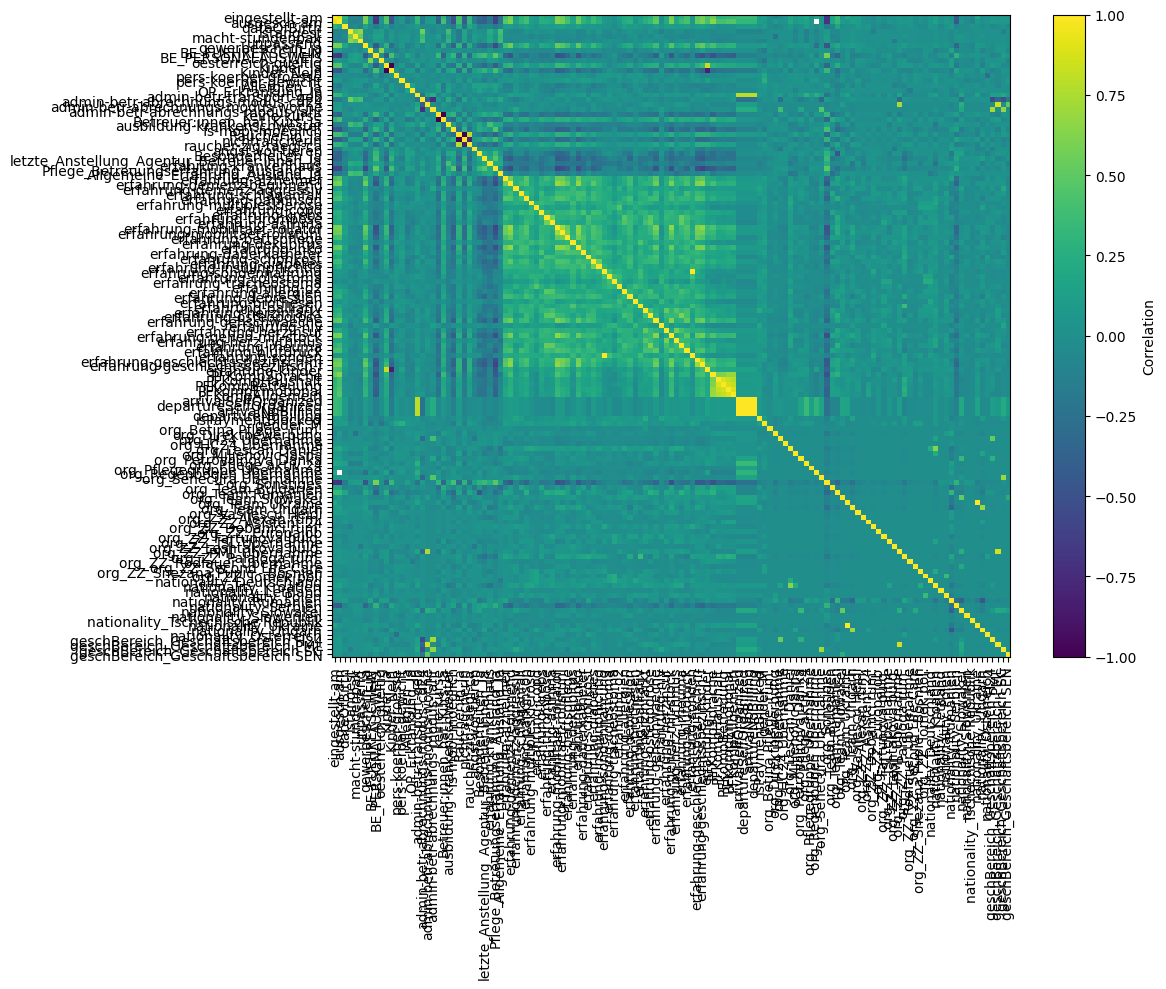

In [41]:
import matplotlib.pyplot as plt

corr = df.drop(columns=["id"]).corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.tight_layout()
plt.show()

In [42]:
def remove_correlated_features(df, threshold=0.8, exclude=["id"]):

    result = df.copy()
    dropped = []

    while True:

        features = result.drop(
            columns=exclude,
            errors="ignore"
        )

        corr = features.corr().abs()

        # Remove diagonal
        np.fill_diagonal(corr.values, 0)

        # Find strongest remaining correlation
        max_corr = corr.max().max()

        if max_corr <= threshold:
            break

        # Find the pair
        var1, var2 = corr.stack().idxmax()

        # Mean absolute correlation with all other variables
        score1 = corr.loc[var1].mean()
        score2 = corr.loc[var2].mean()

        # Drop the more redundant variable
        if score1 > score2:
            drop = var1
        else:
            drop = var2

        dropped.append({
            "dropped": drop,
            "var1": var1,
            "var2": var2,
            "pair_corr": max_corr,
            "score_var1": score1,
            "score_var2": score2
        })

        result = result.drop(columns=drop)

    return result, pd.DataFrame(dropped)

In [43]:
df_reduced, dropped = remove_correlated_features(
    df,
    threshold=0.8,
    exclude=["id", "ausgesch-am", "eingestellt-am"]
)

print(dropped)

                               dropped                                var1  \
0                       nichtraucherin                       Raucher:in_Ja   
1                          Kinder_Nein                           Kinder_Ja   
2           Betreuer:innen_hat_Kurs_Ja                         keine-kurse   
3                     erfahrung-sonden             erfahrung-sondennahrung   
4               departureSelfOrganized                arrivalSelfOrganized   
5                     arrivalNoBilling                arrivalSelfOrganized   
6                 arrivalSelfOrganized                arrivalSelfOrganized   
7                  nationality_Ukraine                    org_Team Ukraine   
8                      PFKompBetreuung                      PFKompHaushalt   
9                      PFKompAllgemein                     PFKompEmotional   
10                org_ZZ_PML Übernahme                org_ZZ_PML Übernahme   
11  admin-betr-abrechnungs-modus-woche  admin-betr-abrechnungs-m

In [44]:
df_reduced

,eingestellt-am,id,ausgesch-am,dateOfBirth,istangest,macht-stundenpak,unpassend,gewerbeschein_ja,BE_FUEHRERSCHEIN,BE_PERSONALAUSWEIS,...,nationality_Serbien,nationality_Slowakei,nationality_Slowenien,nationality_Tschechische Republik,nationality_Ungarn,nationality_Österreich,geschBereich_Geschäftsbereich H24,geschBereich_Geschäftsbereich PML,geschBereich_Geschäftsbereich SC,geschBereich_Geschäftsbereich SEN
2,20190903.0,0025880b-0a6f-d8f3-11f5-87bfa1a5c8f3,20250423.0,19950804,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
5,20260401.0,0033cdc8-5cf7-4b86-7aab-8068d11dae31,NaN,19660712,1,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
6,20150520.0,00390a58-ce9f-cad0-49c3-2ffdd1d1f741,20161117.0,19760531,1,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
8,20130220.0,003f8558-4113-01c8-6489-24e702d243bf,20140201.0,19690105,1,1,1,0,1,1,...,0,0,0,0,0,0,0,0,0,0
9,20251016.0,00411252-62ff-bc52-5ab0-5fbfd476b2a2,20251113.0,19710127,1,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15995,20200910.0,108f39b1-b0a3-27dd-61ad-abc69bf97ccd,20241031.0,19670508,1,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
15996,20180716.0,1099e9c3-ba00-0ab0-fe95-964b42e25e2d,20200306.0,19700625,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
15997,20211027.0,109ccf4f-0b2d-bb18-d97a-1875593ec545,20220307.0,19870921,1,1,1,1,1,0,...,0,0,0,0,1,0,0,0,0,0
15998,20151207.0,109e4a36-28c2-bc19-9552-0c7bee985c9d,20160813.0,19650814,1,1,1,0,0,1,...,0,1,0,0,0,0,0,0,0,0
